# Universal Top-Hat Test (Constant $E_{iso}$, free $\theta_c$)

This notebook is a clean **BNS-only** test (no NSBH).

It uses `z_model = 'fiducial_Hrad_A1.0'` and introduces one Monte Carlo luminosity tweak for constant $E_{iso}$:

$$L_{\mathrm{app}} \propto (1-\cos\theta_c).$$

Here $\theta_c$ is sampled as a model parameter, so this introduces the intended luminosity-$\theta_c$ degeneracy.

In [1]:
%load_ext autoreload
%autoreload 2

import notebook_setup
import src.init
import emcee
import corner
import numpy as np
import matplotlib.pyplot as plt
from math import inf
from pathlib import Path

from src.top_hat.montecarlo import (
    create_k_interpolator,
    create_log_probability_function,
    simplified_montecarlo,
    apply_detection_cuts,
    score_func_cvm,
    poiss_log,
    run_mcmc,
    check_and_resume_mcmc,
)

plt.style.use('../configurations/style.mplstyle')

In [2]:
# Global setup
datafiles = Path('../datafiles')
N_WALKERS = 20
N_STEPS = 20_000
N_PARAMS = 6
PARAM_NAMES = ['A_index', 'L_L0', 'L_mu_E', 'sigma_E', 'theta_c', 'f_j']
MAX_FJ = 10.0

In [3]:
def log_prior_theta_free(thetas):
    A_index, L_L0, L_mu_E, sigma_E, theta_c, fj = thetas

    if not (1.5 < A_index < 5):
        return -inf
    if not (-2 < L_L0 < 6):
        return -inf
    if not (1 < L_mu_E < 6.5):
        return -inf
    if not (0 < sigma_E < 1.8):
        return -inf
    if not (1.0 < theta_c < 50.0):
        return -inf
    if not (0 < fj < MAX_FJ):
        return -inf

    return 0.0


def log_likelihood_theta_free_constant_eiso(thetas, params_in, distances, k_interpolator, n_events=10_000):
    A_index, L_L0, L_mu_E, sigma_E, theta_c, fj = thetas

    theta_c_rad = np.radians(theta_c)
    geometric_factor = 1.0 - np.cos(theta_c_rad)
    epsilon = fj * geometric_factor

    gbm_eff = 0.6
    n_years = params_in.triggered_years
    intrinsic_rate_per_year = epsilon * len(params_in.z_arr) * gbm_eff
    expected_total_events = intrinsic_rate_per_year * n_years

    if expected_total_events < 10:
        return -inf, -inf, -inf, -inf, -inf

    thetas_mc = np.array([A_index, L_L0 + np.log10(geometric_factor), L_mu_E, sigma_E, theta_c, fj])
    results = simplified_montecarlo(thetas_mc, n_events, params_in, distances, k_interpolator)
    trigger_mask, analysis_mask = apply_detection_cuts(results['p_flux'], results['E_p_obs'])

    if np.sum(analysis_mask) <= 3:
        return -inf, -inf, -inf, -inf, -inf

    detected_events = np.sum(trigger_mask)
    detection_efficiency = detected_events / n_events
    predicted_detections = expected_total_events * detection_efficiency

    observed_detections = params_in.yearly_rate * params_in.triggered_years

    l1 = score_func_cvm(results['p_flux'][analysis_mask], params_in.pflux_data, params_in.rng)
    l2 = score_func_cvm(results['E_p_obs'][analysis_mask], params_in.epeak_data, params_in.rng)
    l3 = poiss_log(k=observed_detections, mu=predicted_detections)
    l4 = detection_efficiency

    return l1 + l2 + l3, l1, l2, l3, l4


def initialize_walkers_theta_free(n_walkers):
    np.random.seed(42)
    return np.column_stack([
        np.random.uniform(2, 3, n_walkers),
        np.random.uniform(2, 4.0, n_walkers),
        np.random.uniform(2.0, 4.0, n_walkers),
        np.random.uniform(0.2, 1.0, n_walkers),
        np.random.uniform(2.0, 15.0, n_walkers),
        np.random.uniform(0.5, 2.0, n_walkers),
    ])

In [5]:
# Simulation setup (requested redshift model)
params = {
    'alpha'         : -0.67,
    'beta_s'        : -2.59,
    'n'             : 2,
    'theta_v_max'   : 10, # doesn't matter
    'theta_c'       : 5.0, # doesn't matter
    'z_model'       : 'fiducial_Hrad_A1.0',
}

default_params, _, _ = src.init.initialize_simulation(datafiles, params=params)
k_interpolator = create_k_interpolator()

distances = None
log_prob = create_log_probability_function(
    log_prior_func=log_prior_theta_free,
    log_likelihood_func=log_likelihood_theta_free_constant_eiso,
    params_in=default_params,
    k_interpolator=k_interpolator,
    distances=distances,
    )

print(f'Catalogue events: {len(default_params.pflux_data)}')
print(f'Yearly rate: {default_params.yearly_rate:.2f} GRBs/yr')
print('Constant-Eiso scaling uses sampled theta_c via (1 - cos(theta_c)).')

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Computed total merger rate: 360832.5 yr^-1 (local R_0 = 112.0 Gpc^-3 yr^-1) for component BNSs
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year
Catalogue events: 268
Yearly rate: 18.58 GRBs/yr
Constant-Eiso scaling uses sampled theta_c via (1 - cos(theta_c)).


In [6]:
# Run or resume MCMC
output_dir = src.init.create_run_dir('Paper_Results/Universal_TopHat_thetaFree_constantEiso', use_timestamp=False)
filename = output_dir / 'emcee.h5'

initial_pos, n_steps_to_do, backend = check_and_resume_mcmc(
    filename=filename,
    n_steps=N_STEPS,
    initialize_walkers_func=initialize_walkers_theta_free,
    n_walkers=N_WALKERS,
    )

if n_steps_to_do > 0:
    sampler = run_mcmc(
        log_probability_func=log_prob,
        initial_walkers=initial_pos,
        n_iterations=n_steps_to_do,
        n_walkers=N_WALKERS,
        n_params=N_PARAMS,
        backend=backend,
    )
else:
    print('Run already complete at target steps.')

Creating new directory : Output_files/Paper_Results/Universal_TopHat_thetaFree_constantEiso
Starting new run


  0%|          | 0/20000 [00:00<?, ?it/s]/home/ludo/.local/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 20000/20000 [23:45<00:00, 14.03it/s]


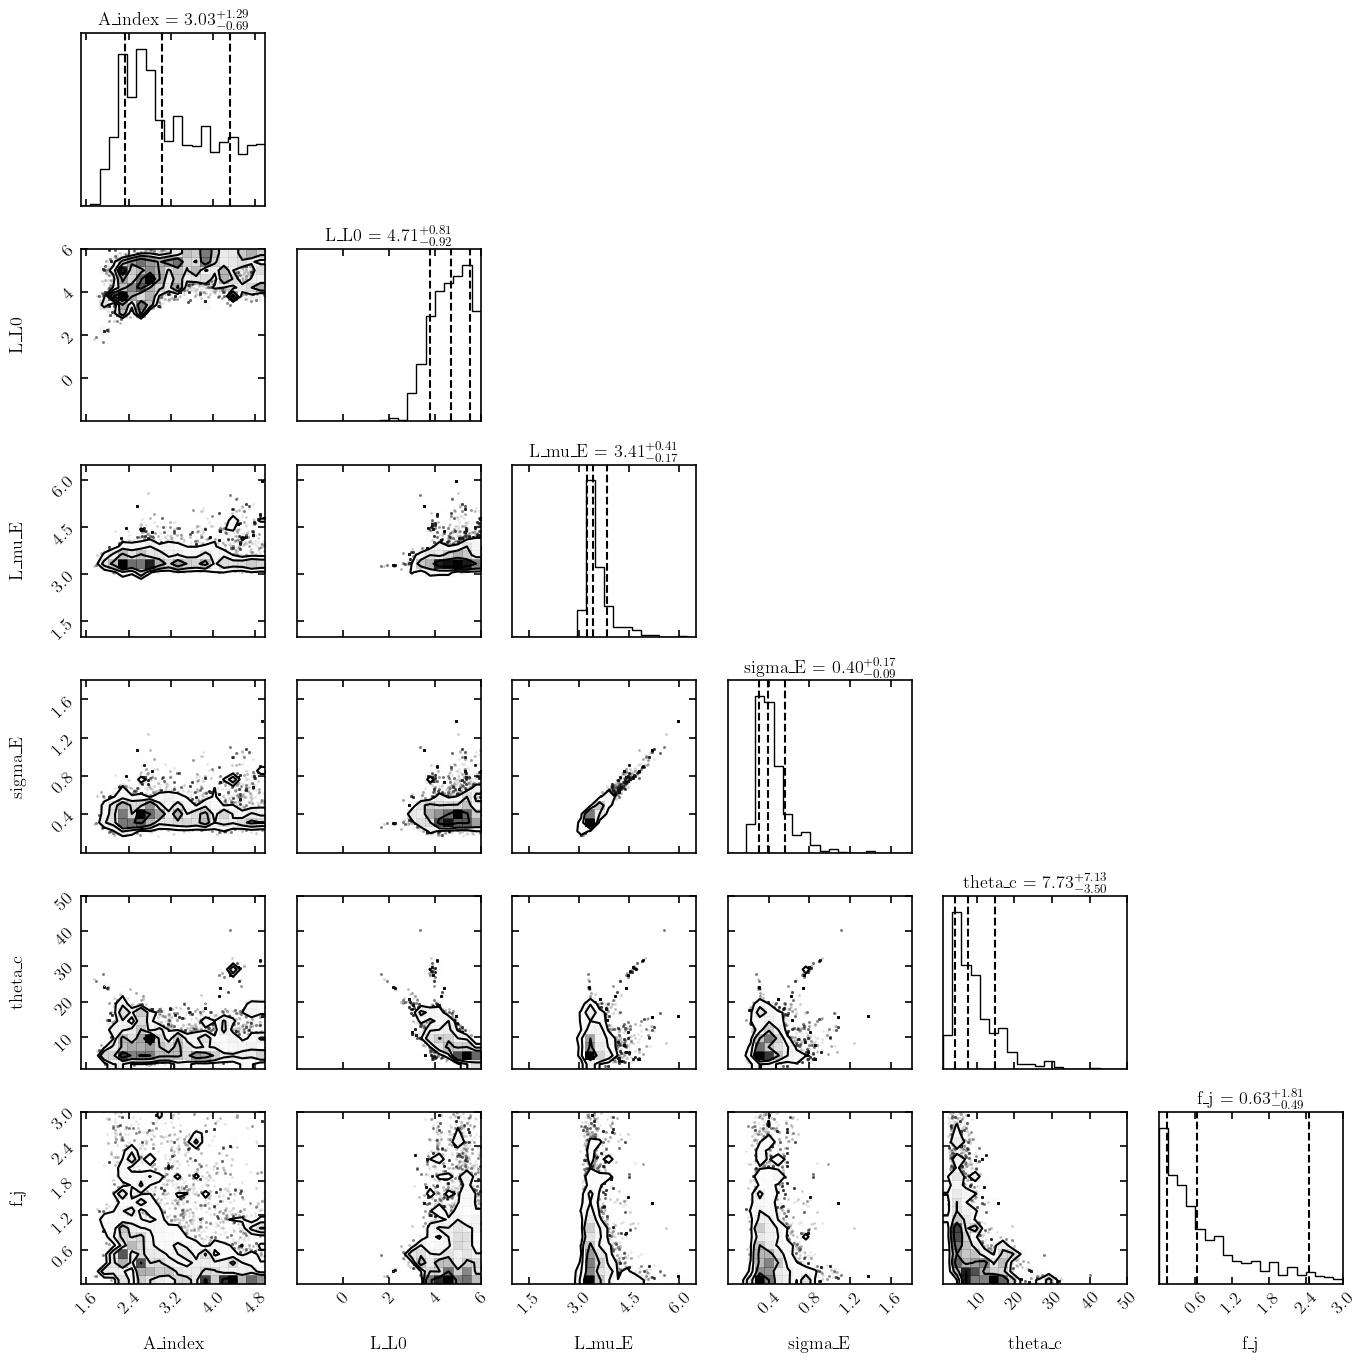

In [7]:
# Corner plot
backend = emcee.backends.HDFBackend(output_dir / 'emcee.h5')
discard = max(1000, backend.iteration // 3)
flat_samples = backend.get_chain(discard=discard, thin=15, flat=True)

plot_ranges = [
    [1.5, 5],
    [-2, 6],
    [1, 6.5],
    [0, 1.8],
    [1, 50],
    [0, 3],
]

figure = corner.corner(
    flat_samples,
    labels=PARAM_NAMES,
    show_titles=True,
    title_fmt='.2f',
    quantiles=[0.16, 0.5, 0.84],
    range=plot_ranges,
    )
plt.tight_layout()
plt.show()